In [ ]:
# =========================
# Cell 0: Clean MediaPipe Tasks setup
# =========================

!pip uninstall -y mediapipe mediapipe-nightly
!pip install -q --no-cache-dir --upgrade mediapipe opencv-python-headless pandas openpyxl

import sys
import cv2
import os
import numpy as np
import pandas as pd
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from google.colab import files
from google.colab.patches import cv2_imshow

print("Python version:", sys.version)
print("MediaPipe version:", mp.__version__)
print("Has mp.Image:", hasattr(mp, "Image"))
print("Has MediaPipe Tasks:", hasattr(mp, "tasks"))
print("FaceLandmarker class:", vision.FaceLandmarker)

# دانلود مدل رسمی Face Landmarker
!wget -q -O face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task

MODEL_PATH = "face_landmarker.task"

print("Model path:", MODEL_PATH)
print("Cell 0 finished.")

Found existing installation: mediapipe 0.10.35
Uninstalling mediapipe-0.10.35:
  Successfully uninstalled mediapipe-0.10.35
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 248.9 MB/s eta 0:00:00
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
MediaPipe version: 0.10.35
Has mp.Image: True
Has MediaPipe Tasks: True
FaceLandmarker class: <class 'mediapipe.tasks.python.vision.face_landmarker.FaceLandmarker'>
Model path: face_landmarker.task
Cell 0 finished.


In [ ]:
# =========================
# Cell 1: Upload video and check video info
# =========================

uploaded = files.upload()

VIDEO_PATH = list(uploaded.keys())[0]
print("Uploaded video:", VIDEO_PATH)

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise ValueError("Video could not be opened. Check the uploaded file.")

video_fps = cap.get(cv2.CAP_PROP_FPS)
video_total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
video_duration_sec = video_total_frames / video_fps if video_fps else 0

print("Video path:", VIDEO_PATH)
print("Original FPS:", video_fps)
print("Original total frames:", video_total_frames)
print("Original duration seconds:", video_duration_sec)

cap.release()

Saving doardoha.mp4 to doardoha.mp4
Uploaded video: doardoha.mp4
Video path: doardoha.mp4
Original FPS: 6.0
Original total frames: 368
Original duration seconds: 61.333333333333336


In [ ]:
# =========================
# Cell 2: Output and synchronization settings
# =========================

OUTPUT_DIR = "/content/vision_lip_outputs"
ANNOTATED_DIR = os.path.join(OUTPUT_DIR, "annotated_frames")
EXCEL_PATH = os.path.join(OUTPUT_DIR, "lip_coordinates_mediapipe_3persons_600frames.xlsx")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(ANNOTATED_DIR, exist_ok=True)

# هماهنگی با فایل صوتی:
# 60 ثانیه صوت = 600 فریم تحلیلی
TARGET_DURATION_SEC = 60
TARGET_ANALYSIS_FPS = 10
TARGET_TOTAL_FRAMES = TARGET_DURATION_SEC * TARGET_ANALYSIS_FPS  # 600

MAX_PERSONS = 3

# برای تست اول True بماند؛ اگر پردازش کند شد بعداً False می‌کنیم
SAVE_ANNOTATED_FRAMES = True

print("Output folder:", OUTPUT_DIR)
print("Annotated frames folder:", ANNOTATED_DIR)
print("Excel path:", EXCEL_PATH)
print("Target duration:", TARGET_DURATION_SEC, "sec")
print("Target analysis FPS:", TARGET_ANALYSIS_FPS)
print("Target total frames:", TARGET_TOTAL_FRAMES)
print("First time_sec:", 0)
print("Last time_sec:", (TARGET_TOTAL_FRAMES - 1) / TARGET_ANALYSIS_FPS)

Output folder: /content/vision_lip_outputs
Annotated frames folder: /content/vision_lip_outputs/annotated_frames
Excel path: /content/vision_lip_outputs/lip_coordinates_mediapipe_3persons_600frames.xlsx
Target duration: 60 sec
Target analysis FPS: 10
Target total frames: 600
First time_sec: 0
Last time_sec: 59.9


Detected poses: 3
Person 1
  mouth_left : 166.74123764038086 74.96264934539795
  mouth_right: 161.29533767700195 73.43376159667969
  mouth_center: 164.0182876586914 74.19820547103882
Person 2
  mouth_left : 287.14099884033203 53.877625465393066
  mouth_right: 275.3221321105957 54.567832946777344
  mouth_center: 281.23156547546387 54.222729206085205
Person 3
  mouth_left : 354.033203125 65.49997329711914
  mouth_right: 340.33103942871094 67.64531135559082
  mouth_center: 347.18212127685547 66.57264232635498
Test frame time: 5.0 sec


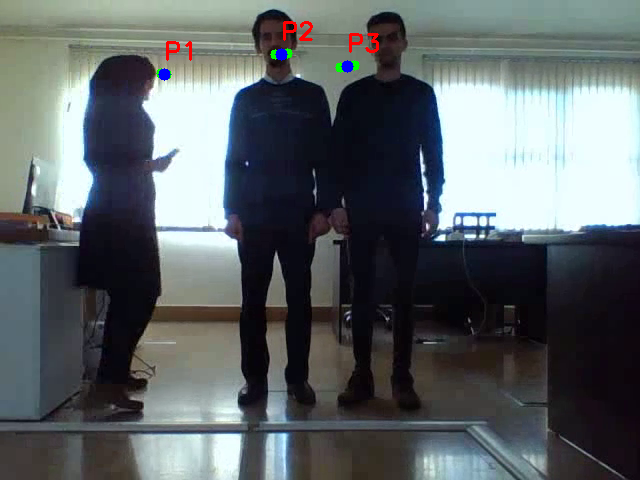

In [ ]:
# =========================
# Cell 3: Test MediaPipe Pose Estimation for mouth coordinates
# =========================

# مدل رسمی MediaPipe Pose Landmarker
!wget -q -O pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

POSE_MODEL_PATH = "pose_landmarker.task"

# در Pose، نقاط دهان این‌ها هستند
MOUTH_LEFT_ID = 9
MOUTH_RIGHT_ID = 10

TEST_TIME_SEC = 5.0

base_options = python.BaseOptions(model_asset_path=POSE_MODEL_PATH)

pose_options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_poses=MAX_PERSONS,
    min_pose_detection_confidence=0.2,
    min_pose_presence_confidence=0.2,
    min_tracking_confidence=0.2
)

pose_detector = vision.PoseLandmarker.create_from_options(pose_options)

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_MSEC, TEST_TIME_SEC * 1000)

success, frame = cap.read()
cap.release()

if not success or frame is None:
    pose_detector.close()
    raise ValueError("Frame could not be read. Try another TEST_TIME_SEC.")

height, width, _ = frame.shape

rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=rgb_frame
)

result = pose_detector.detect(mp_image)

annotated = frame.copy()

if not result.pose_landmarks:
    print("No pose detected in this frame.")
else:
    print("Detected poses:", len(result.pose_landmarks))

    poses_data = []

    for pose_index, pose_landmarks in enumerate(result.pose_landmarks):
        # مرکز بدن/صورت برای مرتب‌سازی چپ به راست
        xs = [lm.x * width for lm in pose_landmarks]
        ys = [lm.y * height for lm in pose_landmarks]

        pose_center_x = float(np.mean(xs))
        pose_center_y = float(np.mean(ys))

        poses_data.append({
            "pose_index": pose_index,
            "pose_landmarks": pose_landmarks,
            "pose_center_x": pose_center_x,
            "pose_center_y": pose_center_y
        })

    # مرتب‌سازی افراد از چپ به راست: P1, P2, P3
    poses_data = sorted(poses_data, key=lambda x: x["pose_center_x"])

    for person_id, pose_data in enumerate(poses_data, start=1):
        pose_landmarks = pose_data["pose_landmarks"]

        mouth_left = pose_landmarks[MOUTH_LEFT_ID]
        mouth_right = pose_landmarks[MOUTH_RIGHT_ID]

        mouth_left_x = mouth_left.x * width
        mouth_left_y = mouth_left.y * height

        mouth_right_x = mouth_right.x * width
        mouth_right_y = mouth_right.y * height

        mouth_center_x = (mouth_left_x + mouth_right_x) / 2
        mouth_center_y = (mouth_left_y + mouth_right_y) / 2

        print(f"Person {person_id}")
        print("  mouth_left :", mouth_left_x, mouth_left_y)
        print("  mouth_right:", mouth_right_x, mouth_right_y)
        print("  mouth_center:", mouth_center_x, mouth_center_y)

        # نقطه چپ دهان
        cv2.circle(
            annotated,
            (int(mouth_left_x), int(mouth_left_y)),
            5,
            (0, 255, 0),
            -1
        )

        # نقطه راست دهان
        cv2.circle(
            annotated,
            (int(mouth_right_x), int(mouth_right_y)),
            5,
            (0, 255, 0),
            -1
        )

        # مرکز دهان
        cv2.circle(
            annotated,
            (int(mouth_center_x), int(mouth_center_y)),
            6,
            (255, 0, 0),
            -1
        )

        cv2.putText(
            annotated,
            f"P{person_id}",
            (int(mouth_center_x), int(mouth_center_y) - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )

pose_detector.close()

print("Test frame time:", TEST_TIME_SEC, "sec")
cv2_imshow(annotated)

In [ ]:
# =========================
# Cell 4: Process 600 frames and save 2 Excel files
# =========================

# چون تو گفتی دو گوینده داری
NUM_SPEAKERS = 2

# landmark های دهان در Pose
MOUTH_LEFT_ID = 9
MOUTH_RIGHT_ID = 10

# مسیر فایل‌های خروجی
SPEAKER1_EXCEL_PATH = os.path.join(OUTPUT_DIR, "speaker_1_mouth_coordinates.xlsx")
SPEAKER2_EXCEL_PATH = os.path.join(OUTPUT_DIR, "speaker_2_mouth_coordinates.xlsx")
COMBINED_EXCEL_PATH = os.path.join(OUTPUT_DIR, "all_speakers_mouth_coordinates.xlsx")

print("Speaker 1 Excel:", SPEAKER1_EXCEL_PATH)
print("Speaker 2 Excel:", SPEAKER2_EXCEL_PATH)
print("Combined Excel :", COMBINED_EXCEL_PATH)

# ساخت Pose detector
base_options = python.BaseOptions(model_asset_path=POSE_MODEL_PATH)

pose_options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_poses=NUM_SPEAKERS,
    min_pose_detection_confidence=0.2,
    min_pose_presence_confidence=0.2,
    min_tracking_confidence=0.2
)

pose_detector = vision.PoseLandmarker.create_from_options(pose_options)

# برای حفظ هویت افراد بین فریم‌ها
previous_centers = {}

# داده‌های هر گوینده
speaker1_rows = []
speaker2_rows = []
all_rows = []

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    pose_detector.close()
    raise ValueError("Video could not be opened.")

def get_pose_center(pose_landmarks, width, height):
    xs = [lm.x * width for lm in pose_landmarks]
    ys = [lm.y * height for lm in pose_landmarks]
    return float(np.mean(xs)), float(np.mean(ys))

def assign_person_ids(poses_data, previous_centers, num_speakers=2):
    """
    poses_data: لیست poseهای detect شده
    previous_centers: مرکز‌های قبلی برای حفظ identity
    خروجی: dict مثل {1: pose_data, 2: pose_data}
    """
    assigned = {}

    if len(poses_data) == 0:
        return assigned

    # اگر اولین فریم معتبر باشد، از چپ به راست شماره بده
    if len(previous_centers) == 0:
        poses_sorted = sorted(poses_data, key=lambda x: x["pose_center_x"])
        for i, pose_data in enumerate(poses_sorted[:num_speakers], start=1):
            assigned[i] = pose_data
        return assigned

    # نزدیک‌ترین match نسبت به مراکز قبلی
    candidate_pairs = []

    for person_id, prev_center in previous_centers.items():
        prev_x, prev_y = prev_center

        for pose_idx, pose_data in enumerate(poses_data):
            cx = pose_data["pose_center_x"]
            cy = pose_data["pose_center_y"]
            dist = np.sqrt((cx - prev_x) ** 2 + (cy - prev_y) ** 2)
            candidate_pairs.append((dist, person_id, pose_idx))

    candidate_pairs = sorted(candidate_pairs, key=lambda x: x[0])

    used_persons = set()
    used_poses = set()

    for dist, person_id, pose_idx in candidate_pairs:
        if person_id not in used_persons and pose_idx not in used_poses:
            assigned[person_id] = poses_data[pose_idx]
            used_persons.add(person_id)
            used_poses.add(pose_idx)

    # اگر pose اضافه مانده بود، به person_id خالی اختصاص بده
    remaining_pose_indices = [i for i in range(len(poses_data)) if i not in used_poses]
    remaining_pose_indices = sorted(remaining_pose_indices, key=lambda i: poses_data[i]["pose_center_x"])

    empty_person_ids = [pid for pid in range(1, num_speakers + 1) if pid not in assigned]

    for pid, pose_idx in zip(empty_person_ids, remaining_pose_indices):
        assigned[pid] = poses_data[pose_idx]

    return assigned

for analysis_frame_id in range(TARGET_TOTAL_FRAMES):

    # زمان متناظر با فایل صوتی: 0.0 تا 59.9
    time_sec = analysis_frame_id / TARGET_ANALYSIS_FPS

    # رفتن به همان زمان در ویدیو
    cap.set(cv2.CAP_PROP_POS_MSEC, time_sec * 1000)
    success, frame = cap.read()

    # اگر فریم خوانده نشد
    if not success or frame is None:
        for speaker_id in range(1, NUM_SPEAKERS + 1):
            row = {
                "frame_id": analysis_frame_id,
                "time_sec": time_sec,
                "speaker_id": speaker_id,
                "detected": 0,
                "mouth_left_x": None,
                "mouth_left_y": None,
                "mouth_right_x": None,
                "mouth_right_y": None,
                "mouth_center_x": None,
                "mouth_center_y": None
            }

            all_rows.append(row)

            if speaker_id == 1:
                speaker1_rows.append(row.copy())
            elif speaker_id == 2:
                speaker2_rows.append(row.copy())

        continue

    height, width, _ = frame.shape

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_frame
    )

    result = pose_detector.detect(mp_image)

    poses_data = []

    if result.pose_landmarks:
        for pose_index, pose_landmarks in enumerate(result.pose_landmarks):
            pose_center_x, pose_center_y = get_pose_center(pose_landmarks, width, height)

            poses_data.append({
                "pose_index": pose_index,
                "pose_landmarks": pose_landmarks,
                "pose_center_x": pose_center_x,
                "pose_center_y": pose_center_y
            })

    assigned_poses = assign_person_ids(
        poses_data=poses_data,
        previous_centers=previous_centers,
        num_speakers=NUM_SPEAKERS
    )

    # آپدیت مرکزها
    for speaker_id, pose_data in assigned_poses.items():
        previous_centers[speaker_id] = (
            pose_data["pose_center_x"],
            pose_data["pose_center_y"]
        )

    # برای هر دو گوینده، ردیف بساز
    for speaker_id in range(1, NUM_SPEAKERS + 1):

        if speaker_id in assigned_poses:
            pose_data = assigned_poses[speaker_id]
            pose_landmarks = pose_data["pose_landmarks"]

            mouth_left = pose_landmarks[MOUTH_LEFT_ID]
            mouth_right = pose_landmarks[MOUTH_RIGHT_ID]

            mouth_left_x = mouth_left.x * width
            mouth_left_y = mouth_left.y * height

            mouth_right_x = mouth_right.x * width
            mouth_right_y = mouth_right.y * height

            mouth_center_x = (mouth_left_x + mouth_right_x) / 2
            mouth_center_y = (mouth_left_y + mouth_right_y) / 2

            row = {
                "frame_id": analysis_frame_id,
                "time_sec": time_sec,
                "speaker_id": speaker_id,
                "detected": 1,
                "mouth_left_x": mouth_left_x,
                "mouth_left_y": mouth_left_y,
                "mouth_right_x": mouth_right_x,
                "mouth_right_y": mouth_right_y,
                "mouth_center_x": mouth_center_x,
                "mouth_center_y": mouth_center_y
            }

        else:
            row = {
                "frame_id": analysis_frame_id,
                "time_sec": time_sec,
                "speaker_id": speaker_id,
                "detected": 0,
                "mouth_left_x": None,
                "mouth_left_y": None,
                "mouth_right_x": None,
                "mouth_right_y": None,
                "mouth_center_x": None,
                "mouth_center_y": None
            }

        all_rows.append(row)

        if speaker_id == 1:
            speaker1_rows.append(row.copy())
        elif speaker_id == 2:
            speaker2_rows.append(row.copy())

    if analysis_frame_id % 50 == 0:
        print(f"Processed {analysis_frame_id}/{TARGET_TOTAL_FRAMES}")

cap.release()
pose_detector.close()

# DataFrame ها
speaker1_df = pd.DataFrame(speaker1_rows)
speaker2_df = pd.DataFrame(speaker2_rows)
all_df = pd.DataFrame(all_rows)

# ذخیره اکسل‌ها
speaker1_df.to_excel(SPEAKER1_EXCEL_PATH, index=False)
speaker2_df.to_excel(SPEAKER2_EXCEL_PATH, index=False)

# فایل ترکیبی هم برای اطمینان ذخیره می‌کنیم
with pd.ExcelWriter(COMBINED_EXCEL_PATH, engine="openpyxl") as writer:
    speaker1_df.to_excel(writer, sheet_name="speaker_1", index=False)
    speaker2_df.to_excel(writer, sheet_name="speaker_2", index=False)
    all_df.to_excel(writer, sheet_name="all_rows", index=False)

print("Done.")
print("Speaker 1 rows:", len(speaker1_df))
print("Speaker 2 rows:", len(speaker2_df))
print("All rows:", len(all_df))

print("\nSample Speaker 1:")
display(speaker1_df.head())

print("\nSample Speaker 2:")
display(speaker2_df.head())

Speaker 1 Excel: /content/vision_lip_outputs/speaker_1_mouth_coordinates.xlsx
Speaker 2 Excel: /content/vision_lip_outputs/speaker_2_mouth_coordinates.xlsx
Combined Excel : /content/vision_lip_outputs/all_speakers_mouth_coordinates.xlsx
Processed 0/600
Processed 50/600
Processed 100/600
Processed 150/600
Processed 200/600
Processed 250/600
Processed 300/600
Processed 350/600
Processed 400/600
Processed 450/600
Processed 500/600
Processed 550/600
Done.
Speaker 1 rows: 600
Speaker 2 rows: 600
All rows: 1200

Sample Speaker 1:


,frame_id,time_sec,speaker_id,detected,mouth_left_x,mouth_left_y,mouth_right_x,mouth_right_y,mouth_center_x,mouth_center_y
0,0,0.0,1,1,174.964314,116.397529,167.884331,116.159084,171.424322,116.278306
1,1,0.1,1,1,175.721817,115.450037,168.098106,115.454342,171.909962,115.452189
2,2,0.2,1,1,175.721817,115.450037,168.098106,115.454342,171.909962,115.452189
3,3,0.3,1,1,175.250015,116.072953,167.736149,116.109889,171.493082,116.091421
4,4,0.4,1,1,175.250015,116.072953,167.736149,116.109889,171.493082,116.091421



Sample Speaker 2:


,frame_id,time_sec,speaker_id,detected,mouth_left_x,mouth_left_y,mouth_right_x,mouth_right_y,mouth_center_x,mouth_center_y
0,0,0.0,2,1,380.108223,119.724362,371.570892,120.018024,375.839558,119.871193
1,1,0.1,2,1,380.547295,116.831160,371.897430,116.969533,376.222363,116.900346
2,2,0.2,2,1,380.547295,116.831160,371.897430,116.969533,376.222363,116.900346
3,3,0.3,2,1,380.651207,119.203849,372.220688,119.832273,376.435947,119.518061
4,4,0.4,2,1,380.651207,119.203849,372.220688,119.832273,376.435947,119.518061


In [ ]:
from google.colab import files

#files.download(SPEAKER1_EXCEL_PATH)
files.download(SPEAKER2_EXCEL_PATH)
files.download(COMBINED_EXCEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# Cell 5: Save annotated frames using extracted mouth coordinates
# =========================

ANNOTATED_DIR = os.path.join(OUTPUT_DIR, "annotated_mouth_frames")
os.makedirs(ANNOTATED_DIR, exist_ok=True)

ANNOTATED_VIDEO_PATH = os.path.join(OUTPUT_DIR, "annotated_mouth_video_600frames.mp4")

print("Annotated frames folder:", ANNOTATED_DIR)
print("Annotated video path:", ANNOTATED_VIDEO_PATH)

# تنظیمات خروجی ویدیو
output_video_fps = TARGET_ANALYSIS_FPS  # 10 fps برای هماهنگی با صوت
video_writer = None

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise ValueError("Video could not be opened.")

for analysis_frame_id in range(TARGET_TOTAL_FRAMES):

    time_sec = analysis_frame_id / TARGET_ANALYSIS_FPS

    cap.set(cv2.CAP_PROP_POS_MSEC, time_sec * 1000)
    success, frame = cap.read()

    if not success or frame is None:
        print(f"Frame {analysis_frame_id} could not be read.")
        continue

    height, width, _ = frame.shape

    # ساخت video writer در اولین فریم معتبر
    if video_writer is None:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        video_writer = cv2.VideoWriter(
            ANNOTATED_VIDEO_PATH,
            fourcc,
            output_video_fps,
            (width, height)
        )

    annotated = frame.copy()

    # ردیف‌های مربوط به همین فریم از خروجی Cell 4
    frame_rows = all_df[all_df["frame_id"] == analysis_frame_id]

    for _, row in frame_rows.iterrows():

        speaker_id = int(row["speaker_id"])
        detected = int(row["detected"])

        if detected == 0:
            continue

        mouth_left_x = row["mouth_left_x"]
        mouth_left_y = row["mouth_left_y"]
        mouth_right_x = row["mouth_right_x"]
        mouth_right_y = row["mouth_right_y"]
        mouth_center_x = row["mouth_center_x"]
        mouth_center_y = row["mouth_center_y"]

        # نقطه چپ دهان
        cv2.circle(
            annotated,
            (int(mouth_left_x), int(mouth_left_y)),
            5,
            (0, 255, 0),
            -1
        )

        # نقطه راست دهان
        cv2.circle(
            annotated,
            (int(mouth_right_x), int(mouth_right_y)),
            5,
            (0, 255, 0),
            -1
        )

        # خط بین دو نقطه دهان
        cv2.line(
            annotated,
            (int(mouth_left_x), int(mouth_left_y)),
            (int(mouth_right_x), int(mouth_right_y)),
            (0, 255, 0),
            2
        )

        # مرکز دهان
        cv2.circle(
            annotated,
            (int(mouth_center_x), int(mouth_center_y)),
            7,
            (255, 0, 0),
            -1
        )

        # برچسب گوینده
        cv2.putText(
            annotated,
            f"Speaker {speaker_id}",
            (int(mouth_center_x), int(mouth_center_y) - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 0, 255),
            2
        )

    # نوشتن شماره فریم و زمان روی تصویر
    cv2.putText(
        annotated,
        f"Frame: {analysis_frame_id} | Time: {time_sec:.1f}s",
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    # ذخیره فریم
    frame_name = f"annotated_frame_{analysis_frame_id:06d}.jpg"
    frame_path = os.path.join(ANNOTATED_DIR, frame_name)
    cv2.imwrite(frame_path, annotated)

    # اضافه کردن به ویدیوی خروجی
    video_writer.write(annotated)

    if analysis_frame_id % 50 == 0:
        print(f"Annotated frame saved: {analysis_frame_id}/{TARGET_TOTAL_FRAMES}")

cap.release()

if video_writer is not None:
    video_writer.release()

print("Done.")
print("Annotated frames saved in:", ANNOTATED_DIR)
print("Annotated video saved at:", ANNOTATED_VIDEO_PATH)

NameError: name 'os' is not defined

In [ ]:
# =========================
# Cell 6: Download outputs
# =========================

from google.colab import files
import shutil

# زیپ کردن عکس‌های annotated
ANNOTATED_ZIP_PATH = os.path.join(OUTPUT_DIR, "annotated_mouth_frames.zip")
shutil.make_archive(
    ANNOTATED_ZIP_PATH.replace(".zip", ""),
    "zip",
    ANNOTATED_DIR
)

print("Downloading Excel files...")
files.download(SPEAKER1_EXCEL_PATH)
files.download(SPEAKER2_EXCEL_PATH)
files.download(COMBINED_EXCEL_PATH)

print("Downloading annotated video...")
files.download(ANNOTATED_VIDEO_PATH)

print("Downloading annotated frames zip...")
files.download(ANNOTATED_ZIP_PATH)